In [8]:
import json
import sys
import os

sys.path.append(os.path.abspath('..'))
from game import RepeatedReferenceGame, Trial

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from tqdm import tqdm
from scipy import stats
from transformers import AutoProcessor

In [9]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [10]:
from nltk.tokenize import word_tokenize as tokenize
from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))
from nltk.stem.porter import *
stemmer = PorterStemmer()

In [11]:
processor = AutoProcessor.from_pretrained("saujasv/pixtral-12b")

In [12]:
def editDistance(h, r, sent_len=None):
    #Reference: https://github.com/zszyellow/WER-in-python/blob/master/wer.py
    '''
    This function is to calculate the edit distance of reference sentence and the hypothesis sentence.

    Main algorithm used is dynamic programming.

    Attributes: 
        r -> the list of words produced by splitting reference sentence.
        h -> the list of words produced by splitting hypothesis sentence.
    '''
    d = np.zeros((len(r)+1)*(len(h)+1), dtype=np.uint8).reshape((len(r)+1, len(h)+1))
    for i in range(len(r)+1):
        d[i][0] = i
    for j in range(len(h)+1):
        d[0][j] = j
    for i in range(1, len(r)+1):
        for j in range(1, len(h)+1):
            if r[i-1] == h[j-1]:
                d[i][j] = d[i-1][j-1]
            else:
                substitute = d[i-1][j-1]+1
                insert = d[i][j-1]+1 
                delete = d[i-1][j]
                d[i][j] = min(substitute, insert, delete)
    # d=d[len(r)][len(h)]/len(r)
    d=d[len(r)][len(h)]
    
    if len(r)!=0:
        wnr=d/len(r)
        
    else:
        wnr=1 

    return d, wnr

def get_msg_distance(sentences):
    lemmatized_sentences = []
    sentences_lemma=[]
    for sentence in sentences:
        sentence = sentence.strip().strip('.').lower()
        doc = nlp(sentence)
        
     
        filtered_sentence_lemma = []
        for token in doc:
            if token.pos_ in ["NOUN", "ADJ", "VERB", "ADV", 'PROPN','NUM','PRON','ADP']:
                token_lemma=token.lemma_
                filtered_sentence_lemma.append(token_lemma)
          
        lemmatized_sentences.append(' '.join(filtered_sentence_lemma))
        sentences_lemma.append(filtered_sentence_lemma)

    wnd, wnr=editDistance(sentences_lemma[1], sentences_lemma[0])

    return wnd, wnr

In [13]:
def snd(utterance_list):
    if len(utterance_list) == 1:
        return 0

    processed = [[stemmer.stem(w) for w in tokenize(u.lower()) if w not in stop_words and (w.islower() or w.isalnum())] for u in utterance_list]
    utterance_W = []
    for i, utterance in enumerate(processed):
        token_W = []
        for j, token in enumerate(utterance):
            denominator = len(utterance_list) - 1
            num_unseen = 0
            for k, alt_utterance in enumerate(processed):
                if i == k:
                    continue
                k_tokens = set(alt_utterance)
                if token not in k_tokens:
                    num_unseen += 1
            token_W.append(num_unseen / denominator)
        utterance_W.append(np.mean(token_W))
    return np.mean(utterance_W).item()

In [42]:
with open("standard.json") as f:
    data_standard = json.load(f)

df_standard_list = list()
for k, v in tqdm(data_standard.items()):
    game_id, trial_idx, sample_idx = re.match(r"([^_]+)_trialidx=(\d+)_sampleidx=(\d+)", k).groups()
    block_idx = {x: list() for x in v[0]['context']}
    for t in v[0]['trials']:
        block_idx[t['target']].append(t['message'])

    message = v[0]['trials'][-1]['message']
    correct = v[0]['trials'][-1]['correct']
    # if len(block_idx[v[0]['trials'][-1]['target']]) > 1:
    #     wnr, wnd = get_msg_distance((message, block_idx[v[0]['trials'][-1]['target']][-2]))
    # else:
    #     wnr, wnd = None, None
    message_len = len(processor.tokenizer.encode(message))
    df_standard_list.append({
        'condition': 'finetuned-speaker',
        'game_id': game_id,
        'trial_idx': int(trial_idx),
        'block_idx': len(block_idx[v[0]['trials'][-1]['target']]),
        # 'target_length': None,
        'sample_idx': int(sample_idx),
        'message': message,
        'message_len': message_len,
        'correct': correct,
        'context': v[0]['context'],
        'target': v[0]['trials'][-1]['target'],
        # 'wnr': wnr,
        # 'wnd': wnd,
    })

100%|██████████| 18000/18000 [00:00<00:00, 27069.67it/s]


In [43]:
with open("pixtral_listener_human.json") as f:
    data_human = json.load(f)

df_human_list = list()

for gameid, game in data_human.items():
    block_idx = {x: list() for x in game['context']}
    for i, trial in enumerate(game['trials']):
        block_idx[trial['target']].append(trial['message'])
        message = trial['message']
        if message is None:
            continue
        correct = trial['correct']
        # if len(block_idx[trial['target']]) > 1:
        #     if message is None or block_idx[trial['target']][-2] is None:
        #         wnr, wnd = None, None
        #     else:
        #         wnr, wnd = get_msg_distance((message, block_idx[trial['target']][-2]))
        # else:
        #     wnr, wnd = None, None
        message_len = len(processor.tokenizer.encode(message))
        df_human_list.append({
            'condition': 'human',
            'game_id': gameid,
            'trial_idx': i,
            'block_idx': len(block_idx[trial['target']]),
            'sample_idx': 0,
            'message': message,
            'message_len': message_len,
            'correct': correct,
            'context': game['context'],
            'target': trial['target'],
            # 'wnr': wnr,
            # 'wnd': wnd,
        })

In [44]:
df = pd.DataFrame(df_standard_list + df_human_list)

Text(0, 0.5, 'WNR')

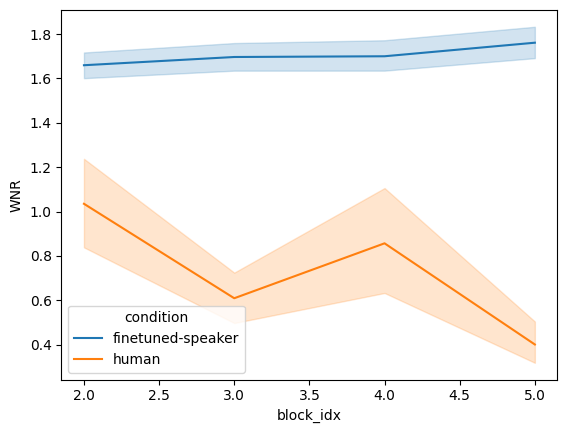

In [33]:
sns.lineplot(data=df, x='block_idx', y='wnd', hue='condition')
plt.ylabel("WNR")

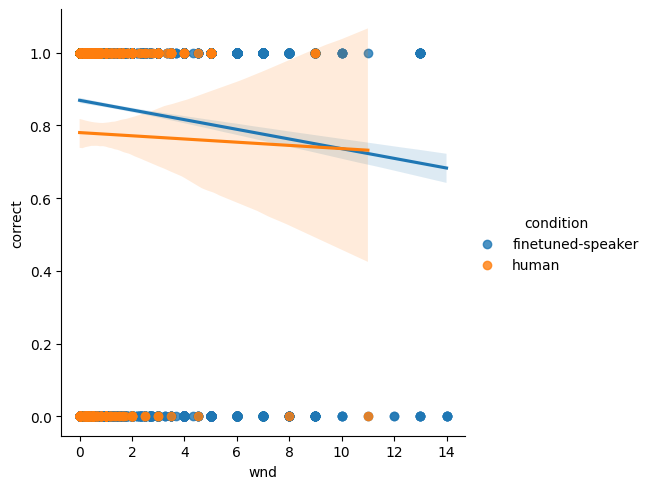

In [39]:
sns.lmplot(data=df, x='wnd', y='correct', hue='condition')

/Users/saujasvs/miniconda3/envs/tangrams/lib/python3.12/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/Users/saujasvs/miniconda3/envs/tangrams/lib/python3.12/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


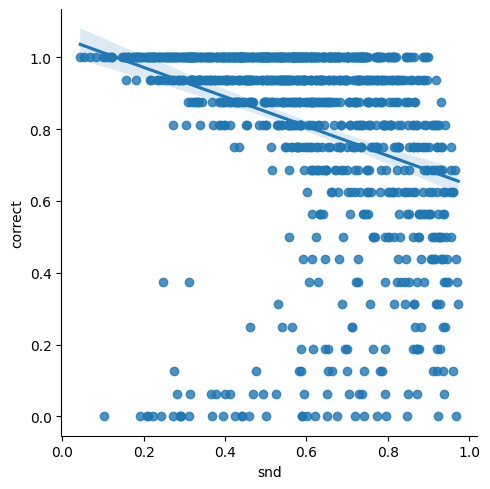

In [31]:
agg_stats_df = df[(df.condition == 'finetuned-speaker')].groupby(['game_id', 'trial_idx'])[['message', 'correct']].apply(lambda x: pd.Series({'snd': snd(x['message']), 'correct': np.mean(x['correct'])})).reset_index().dropna()
sns.lmplot(data=agg_stats_df, x='snd', y='correct')

In [35]:
pearson_corr, p_value = stats.pearsonr(agg_stats_df['snd'], agg_stats_df['correct'])
pearson_corr, p_value

(-0.4785076481562536, 3.2138248907592596e-14)

<Axes: xlabel='block_idx', ylabel='message_len'>

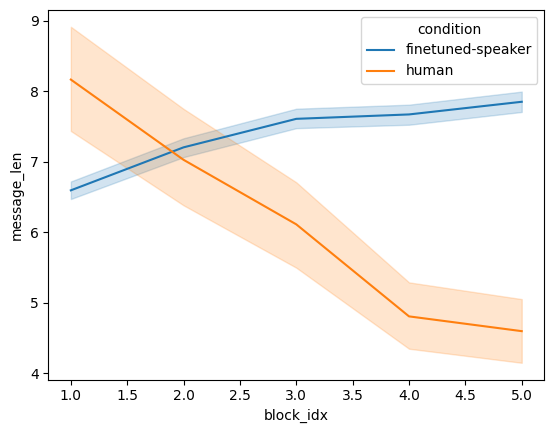

In [32]:
sns.lineplot(data=df, x='block_idx', y='message_len', hue='condition')

<Axes: xlabel='block_idx', ylabel='correct'>

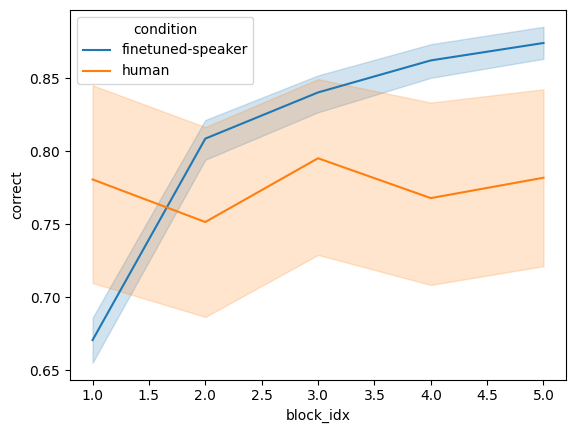

In [39]:
sns.lineplot(data=df, x='block_idx', y='correct', hue='condition')

In [ ]:
sns.countplot(data=df[df.condition == 'length_condition'], x='message_len')

In [40]:
df

,condition,game_id,trial_idx,block_idx,sample_idx,message,message_len,correct,wnr,wnd
0,finetuned-speaker,GJ9acNnSs4GtJvHLn,0,1,0,a person looking down,4,False,NaN,NaN
1,finetuned-speaker,GJ9acNnSs4GtJvHLn,0,1,1,a hand,2,True,NaN,NaN
2,finetuned-speaker,GJ9acNnSs4GtJvHLn,0,1,2,a candle,2,True,NaN,NaN
3,finetuned-speaker,GJ9acNnSs4GtJvHLn,0,1,3,a sink with a faucet,7,False,NaN,NaN
4,finetuned-speaker,GJ9acNnSs4GtJvHLn,0,1,4,a snail,3,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
18818,human,eopF622nhHAfYBAbw,20,5,0,Giant bat with wings,5,True,1.0,0.250000
18819,human,eopF622nhHAfYBAbw,21,5,0,Fountain made up of triangles,6,True,0.0,0.000000
18820,human,eopF622nhHAfYBAbw,22,5,0,Letter 'J',4,True,0.0,0.000000
18821,human,eopF622nhHAfYBAbw,23,5,0,Low flat bridge with two triangles cut out,8,True,1.0,0.125000


In [45]:
df.game_id.unique()

array(['GJ9acNnSs4GtJvHLn', 'RgiXtnKrXiiHQZpcz', 'ZcWh2SAbYaKsBjERa',
       'YjNav28ajaN8MaDor', '7ECfJqZSjjsz8oBCM', 'vmDdBxQwuwh9zvF8P',
       'kp8BgbK6wvnYPuQGY', '8RoqYM3LR5QpJwzT5', 'NsiBXAJpHkx8tDfWh',
       'nyKhaA53drqLC7Rzk', 'CNAiKT7Av6y2oHwvy', 'm6gdcycAbx6zidczq',
       '6oDZZokaTPbFbFyxq', 'jKTvqGPmLEETosBRv', 'r7729FXFMtEsfEXpt',
       'd8wBFJSAzTXrSi2Ro', '3ary6q5mdMWTh8EFJ', 'nf5oZri8MdxJqkW3r',
       'ybLJmKm4ZdQZgZ3Rg', 'Cf5fFT4QPbByXSB5s', 'h3DszyAzWvDeNDqFi',
       'FvSgGZcaE85QgqXam', 'qyNNn9TwYfGcsQ7HL', 'mQXjWgrEfavDMEW9H',
       'te8aFGdFvzCg2sQmZ', 'C4BE3Bcky8iq2Dip5', 'jE8JMgZXZtXkxhbZL',
       'r7FgehPJbtZPJf2uv', 'qihX9gdsRc9rBMRTu', 'YBd2adukpGvYkJvtG',
       'KtmmR6GzmqDdjN8LM', 'KCgt2qJ7K79xySLRm', 'Gk2kEho6sFLNkapKy',
       'SjEpBubywARjBE4T6', 'eopF622nhHAfYBAbw', 'uYTuYuJ9QDfA83X3a',
       'KJeMAhHTjaCs9sMpk', 'qFYGF2GyuhMD4dLKq', 'M5ui5knKYuwwDLr9i',
       'McsJhwH9t5b9tLX8Z', 'vMHoRDsLSDf4mqn9X', 'NBDRu7N7ZS8cWHsSp',
       'Xmax5bZuQDhS

In [49]:
print(df[df.game_id == 'nyKhaA53drqLC7Rzk'].to_string())

               condition            game_id  trial_idx  block_idx  sample_idx                                                                                   message  message_len  correct                                                                      context         target
3600   finetuned-speaker  nyKhaA53drqLC7Rzk          0          1           0                                                           a claw with a claw, and a thumb            9     True  [page6-109.png, page2-131.png, page5-155.png, page7-177.png, page4-142.png]  page4-142.png
3601   finetuned-speaker  nyKhaA53drqLC7Rzk          0          1           1                                                                                 a lobster            3     True  [page6-109.png, page2-131.png, page5-155.png, page7-177.png, page4-142.png]  page4-142.png
3602   finetuned-speaker  nyKhaA53drqLC7Rzk          0          1           2                                      a person holding an umbrella with an ar

In [55]:
def create_html_page(df, output_file='output.html'):
    html_template = '''
    <html>
    <head>
        <style>
            .container { max-width: 1200px; margin: 20px auto; padding: 20px; }
            .message { background: #f0f0f0; padding: 15px; margin-bottom: 20px; }
            .image-grid { display: grid; grid-template-columns: repeat(5, 1fr); gap: 10px; }
            .image-container { border: 2px solid #ddd; padding: 10px; text-align: center; }
            .target { border-color: blue; background: #f0f4ff; }
            .filename { font-size: 12px; margin-top: 5px; }
        </style>
    </head>
    <body>
    '''

    for _, row in df.iterrows():
        context = row['context']  # Convert string list to actual list
        html_content = f'''
        <div class="container">
            <div class="message">Block {row['block_idx']}: {row['message']}</div>
            <div class="image-grid">
        '''
        
        for img in context:
            is_target = img == row['target']
            html_content += f'''
                <div class="image-container {'target' if is_target else ''}">
                    <img src="square-black-imgs/{img}" width="200" height="200">
                    <div class="filename">{img}</div>
                    {f'<div style="color: blue;">Target</div>' if is_target else ''}
                </div>
            '''
        
        html_content += '</div></div>'
        html_template += html_content

    html_template += '</body></html>'
    
    with open(output_file, 'w') as f:
        f.write(html_template)

In [51]:
df = df.sample(n=len(df), random_state=42)

In [56]:
create_html_page(df[df.condition == 'finetuned-speaker'], 'finetuned-speaker.html')